In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
data = pd.read_csv('fiberbits.csv')
data.info()
data.describe()

<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 9 columns):
 #   Column                      Non-Null Count   Dtype
---  ------                      --------------   -----
 0   active_cust                 100000 non-null  int64
 1   income                      100000 non-null  int64
 2   months_on_network           100000 non-null  int64
 3   Num_complaints              100000 non-null  int64
 4   number_plan_changes         100000 non-null  int64
 5   relocated                   100000 non-null  int64
 6   monthly_bill                100000 non-null  int64
 7   technical_issues_per_month  100000 non-null  int64
 8   Speed_test_result           100000 non-null  int64
dtypes: int64(9)
memory usage: 6.9 MB


,active_cust,income,months_on_network,Num_complaints,number_plan_changes,relocated,monthly_bill,technical_issues_per_month,Speed_test_result
count,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.00000,100000.000000,100000.00000
mean,0.421410,1855.279910,58.402450,6.014330,1.385410,0.123480,54.88705,3.885440,53.48643
std,0.493787,2712.385257,18.643736,2.731205,1.617101,0.328989,26.22690,1.690859,19.17461
min,0.000000,1130.000000,-20.000000,0.000000,0.000000,0.000000,10.00000,2.000000,15.00000
25%,0.000000,1674.000000,47.000000,5.000000,0.000000,0.000000,32.00000,3.000000,40.00000
50%,0.000000,1805.000000,56.000000,6.000000,1.000000,0.000000,55.00000,4.000000,54.00000
75%,1.000000,1907.000000,70.000000,8.000000,2.000000,0.000000,78.00000,5.000000,68.00000
max,1.000000,229821.000000,449.000000,10.000000,9.000000,1.000000,100.00000,12.000000,90.00000


In [3]:
data[data['months_on_network'] < 0]

,active_cust,income,months_on_network,Num_complaints,number_plan_changes,relocated,monthly_bill,technical_issues_per_month,Speed_test_result
53552,0,4173,-1,9,0,0,92,2,60
54225,0,5314,-5,7,0,0,69,3,40
54226,0,5321,-6,10,0,0,35,2,18
54227,0,5313,-5,9,0,0,93,3,19
54228,0,5314,-5,10,0,0,70,2,42
...,...,...,...,...,...,...,...,...,...
74565,0,8281,-11,8,0,0,78,3,38
74566,0,8275,-11,7,0,0,99,2,68
74567,0,8274,-12,6,0,0,11,2,48
74568,0,8280,-11,9,0,0,15,2,37


In [4]:
# months_on_network — negative values are invalid, replace with median
data.loc[data['months_on_network'] < 0, 'months_on_network'] = np.nan
data.fillna({'months_on_network': data['months_on_network'].median()}, inplace=True)

,active_cust,income,months_on_network,Num_complaints,number_plan_changes,relocated,monthly_bill,technical_issues_per_month,Speed_test_result
0,1,1586,85.0,6,1,0,42,3,52
1,1,1581,85.0,6,1,0,66,4,66
2,1,1594,82.0,4,1,0,36,4,74
3,1,1594,82.0,5,1,0,37,4,67
4,0,1609,80.0,10,1,0,85,4,48
...,...,...,...,...,...,...,...,...,...
99995,0,1673,71.0,9,2,0,46,5,37
99996,0,1667,71.0,5,2,0,48,4,51
99997,0,1672,71.0,10,2,0,85,5,21
99998,0,1686,69.0,5,2,0,34,4,23


In [5]:
data[data['months_on_network'] < 0]

,active_cust,income,months_on_network,Num_complaints,number_plan_changes,relocated,monthly_bill,technical_issues_per_month,Speed_test_result


In [6]:
data.duplicated().sum()

np.int64(15)

In [7]:
data[data.duplicated(keep=False)].sort_values(by=list(data.columns))

,active_cust,income,months_on_network,Num_complaints,number_plan_changes,relocated,monthly_bill,technical_issues_per_month,Speed_test_result
68612,0,1613,79.0,5,2,0,69,5,57
98187,0,1613,79.0,5,2,0,69,5,57
3536,0,1638,76.0,7,1,0,38,4,50
62020,0,1638,76.0,7,1,0,38,4,50
13350,0,1692,68.0,6,0,0,14,2,60
13808,0,1692,68.0,6,0,0,14,2,60
52402,0,1801,56.0,10,2,0,34,5,70
85533,0,1801,56.0,10,2,0,34,5,70
52014,0,1829,53.0,10,0,0,28,2,21
54076,0,1829,53.0,10,0,0,28,2,21


In [8]:
data.drop_duplicates(inplace=True)

In [9]:
data.isnull().sum()

active_cust                   0
income                        0
months_on_network             0
Num_complaints                0
number_plan_changes           0
relocated                     0
monthly_bill                  0
technical_issues_per_month    0
Speed_test_result             0
dtype: int64

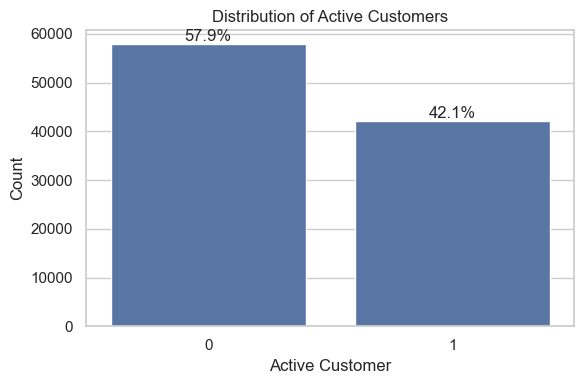

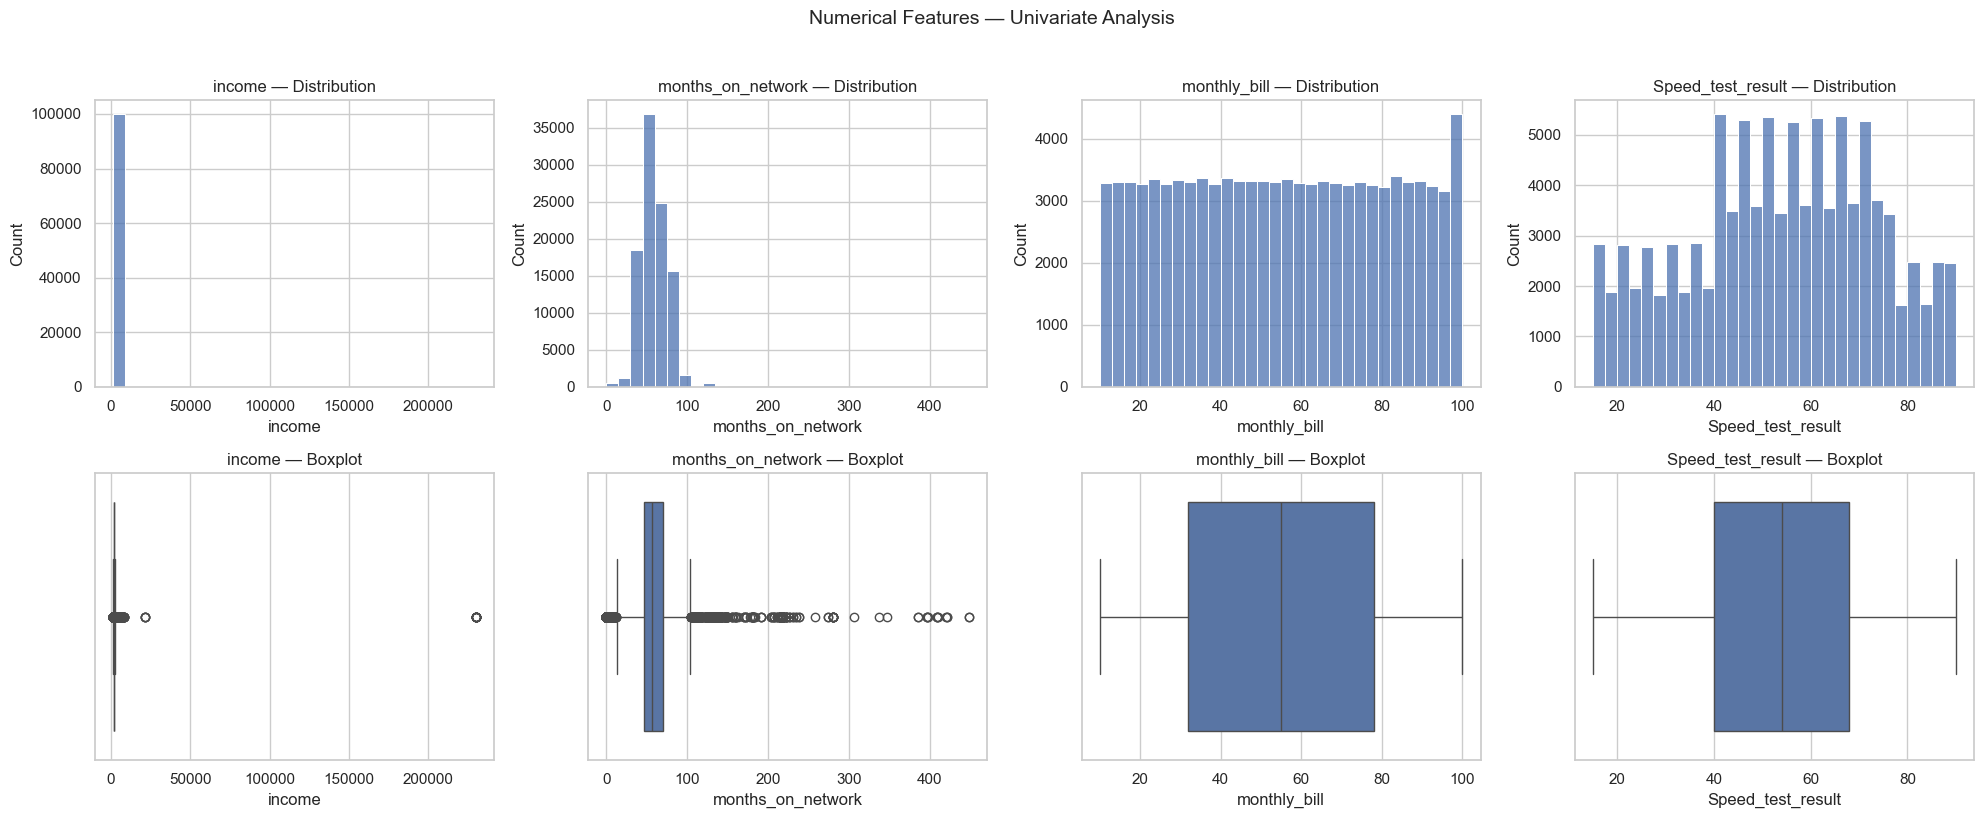

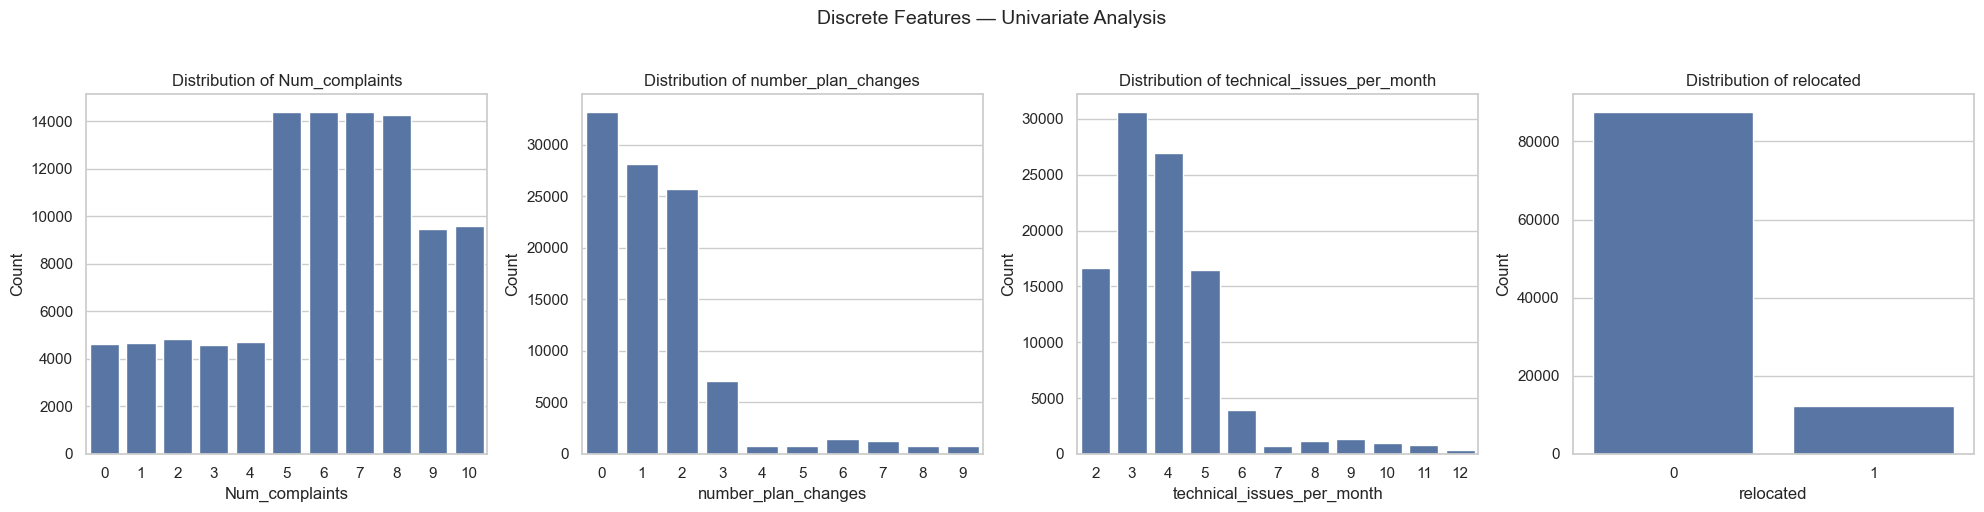

In [10]:
sns.set(style="whitegrid")

# -------------------------------
# 1. TARGET VARIABLE
# -------------------------------
fig, ax = plt.subplots(figsize=(6, 4))
sns.countplot(x='active_cust', data=data, ax=ax)

total = len(data)
for p in ax.patches:
    percentage = 100 * p.get_height() / total
    ax.annotate(f'{percentage:.1f}%',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom')

plt.title('Distribution of Active Customers')
plt.xlabel('Active Customer')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

# -------------------------------
# 2. NUMERICAL FEATURES
# -------------------------------
num_cols = ['income', 'months_on_network', 'monthly_bill', 'Speed_test_result']

fig, axes = plt.subplots(2, 4, figsize=(20, 8))

for i, col in enumerate(num_cols):
    # Histogram
    sns.histplot(data[col], bins=30, ax=axes[0, i])
    axes[0, i].set_title(f'{col} — Distribution')
    axes[0, i].set_xlabel(col)

    # Boxplot
    sns.boxplot(x=data[col], ax=axes[1, i])
    axes[1, i].set_title(f'{col} — Boxplot')
    axes[1, i].set_xlabel(col)

plt.suptitle('Numerical Features — Univariate Analysis', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

# -------------------------------
# 3. DISCRETE / COUNT FEATURES
# -------------------------------
discrete_cols = [
    'Num_complaints',
    'number_plan_changes',
    'technical_issues_per_month',
    'relocated'
]

fig, axes = plt.subplots(1, 4, figsize=(20, 5))

for i, col in enumerate(discrete_cols):
    sns.countplot(x=col, data=data, ax=axes[i])
    axes[i].set_title(f'Distribution of {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Count')

plt.suptitle('Discrete Features — Univariate Analysis', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

In [11]:
# Income — cap outliers using IQR
q1 = data['income'].quantile(0.25)
q3 = data['income'].quantile(0.75)
iqr = q3 - q1
lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr
print("Lower outliers count:", len(data[data['income'] < lower_bound]))
print("Upper outliers count:", len(data[data['income'] > upper_bound]))
data['income'] = data['income'].clip(lower=lower_bound, upper=upper_bound)

Lower outliers count: 121
Upper outliers count: 1301


<Axes: xlabel='income', ylabel='Count'>

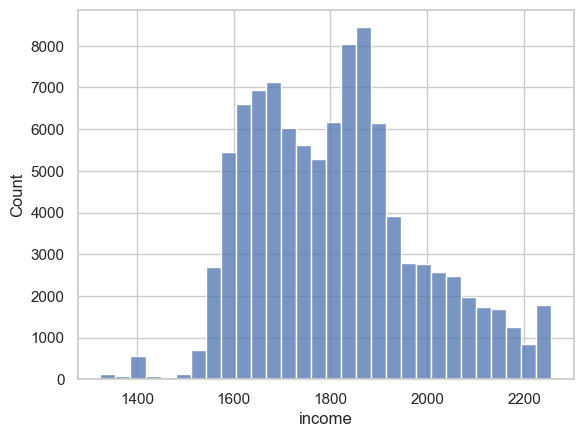

In [12]:
sns.histplot(data=data['income'], bins=30)

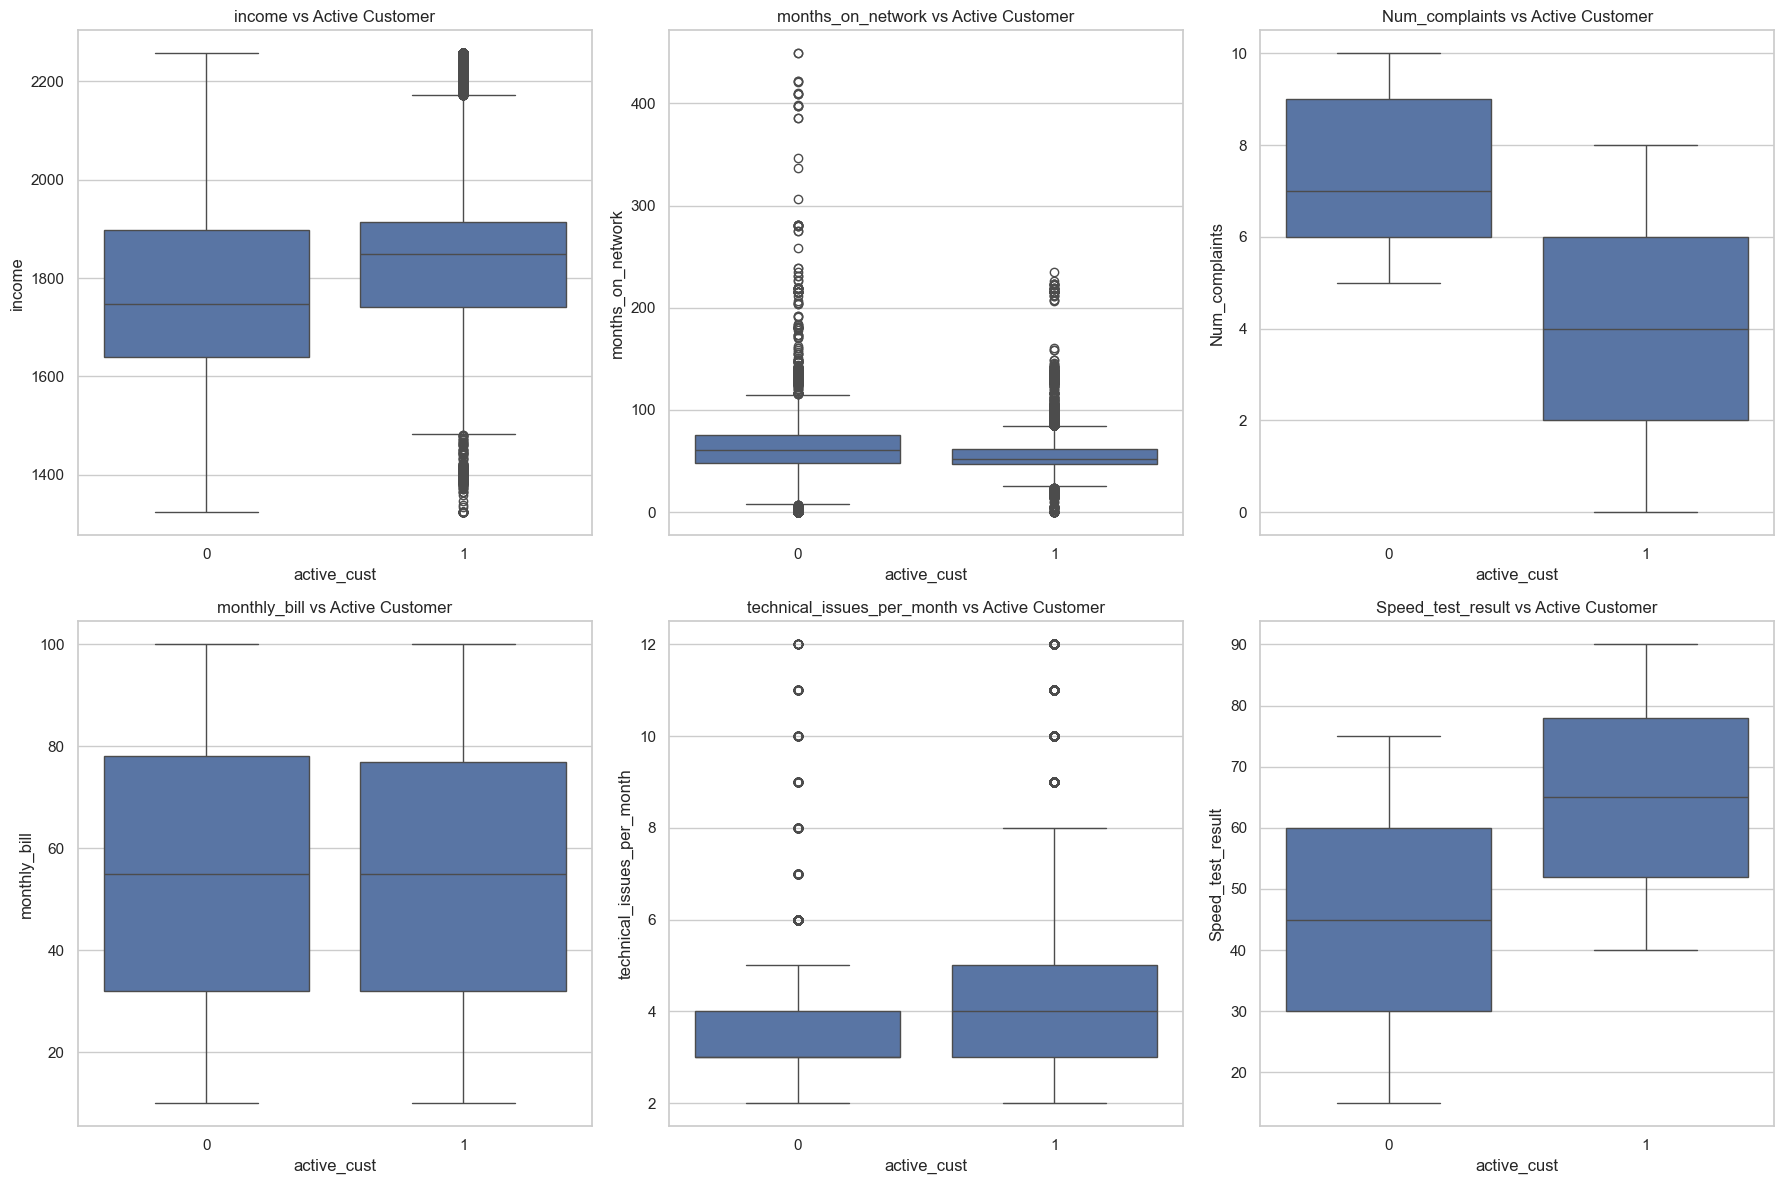


📊 Mean values grouped by active_cust:

                  income  months_on_network  Num_complaints  monthly_bill  \
active_cust                                                                 
0            1783.697895          61.485454        7.487199     54.993863   
1            1848.787367          54.299150        3.991978     54.742833   

             technical_issues_per_month  Speed_test_result  
active_cust                                                 
0                              3.493561          45.093053  
1                              4.423676          65.008235  


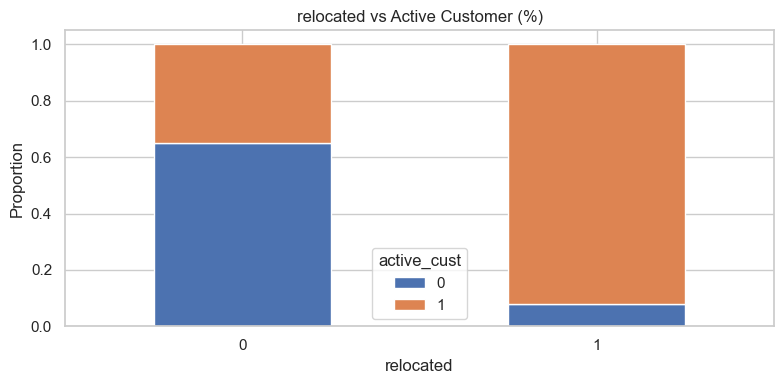


relocated vs active_cust (proportions):

active_cust      0      1
relocated                
0            0.649  0.351
1            0.077  0.923
----------------------------------------


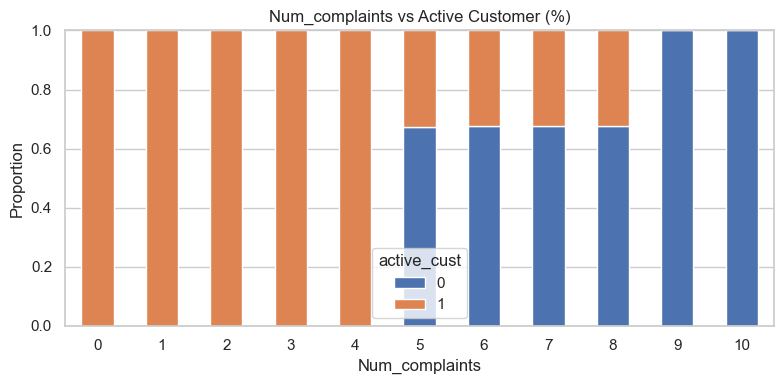


Num_complaints vs active_cust (proportions):

active_cust         0      1
Num_complaints              
0               0.000  1.000
1               0.000  1.000
2               0.000  1.000
3               0.000  1.000
4               0.000  1.000
5               0.673  0.327
6               0.676  0.324
7               0.676  0.324
8               0.676  0.324
9               1.000  0.000
10              1.000  0.000
----------------------------------------


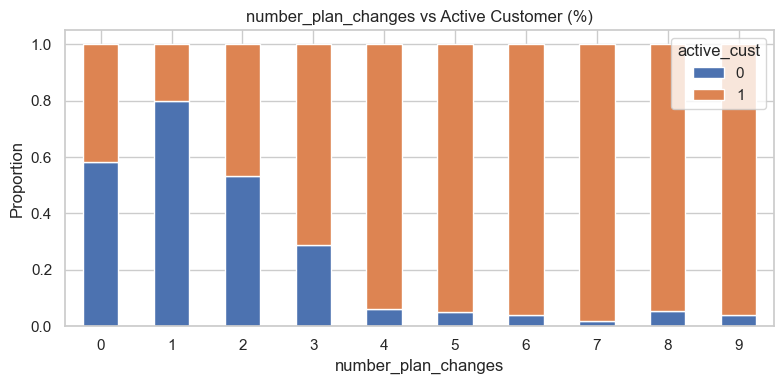


number_plan_changes vs active_cust (proportions):

active_cust              0      1
number_plan_changes              
0                    0.582  0.418
1                    0.799  0.201
2                    0.534  0.466
3                    0.288  0.712
4                    0.062  0.938
5                    0.049  0.951
6                    0.040  0.960
7                    0.018  0.982
8                    0.053  0.947
9                    0.038  0.962
----------------------------------------


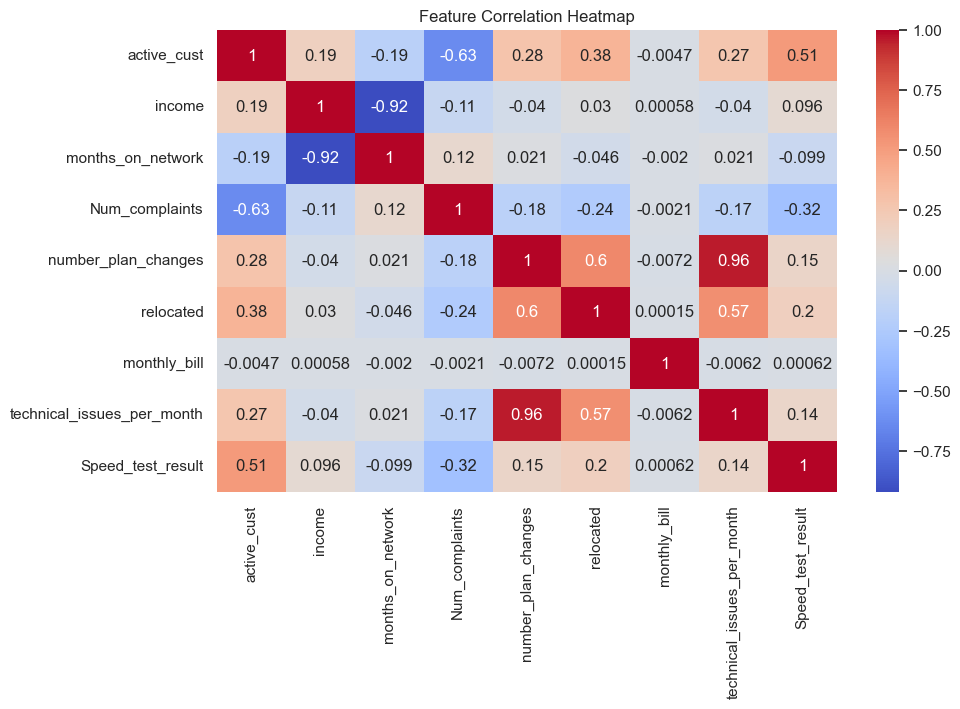

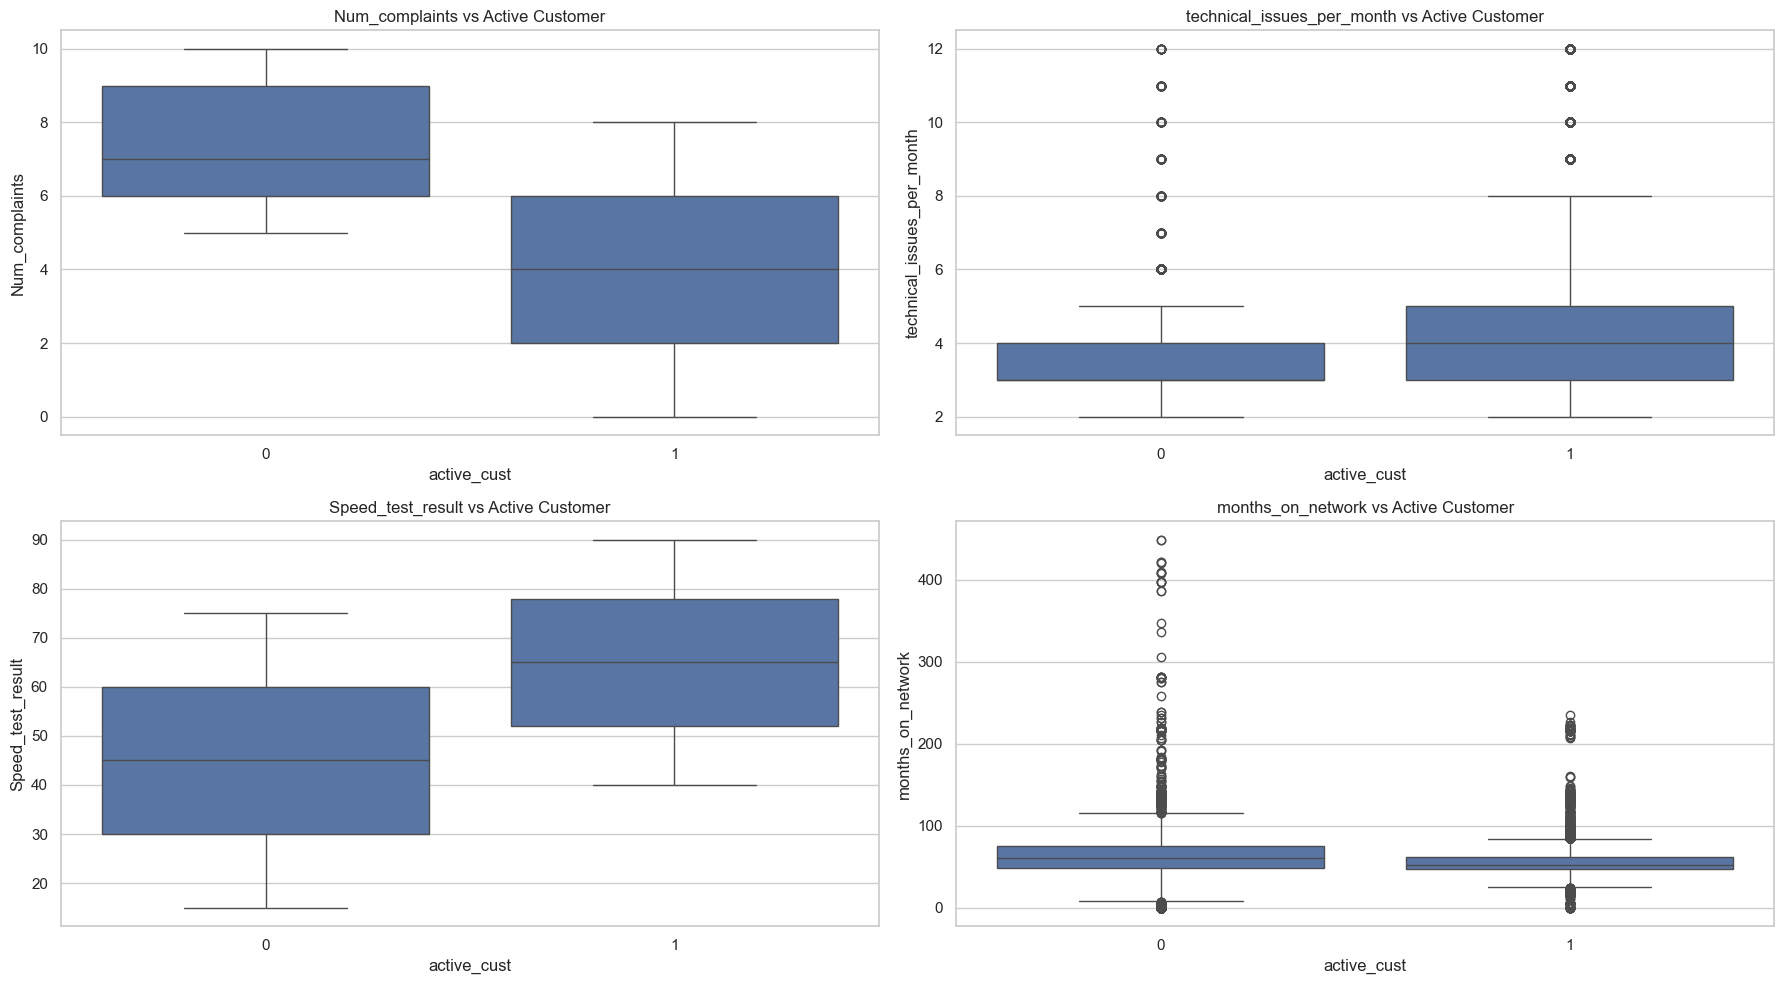

In [13]:
sns.set(style="whitegrid")

# -------------------------------
# 1. NUMERICAL vs TARGET (Boxplots)
# -------------------------------
num_cols = [
    'income',
    'months_on_network',
    'Num_complaints',
    'monthly_bill',
    'technical_issues_per_month',
    'Speed_test_result'
]

plt.figure(figsize=(18, 12))

for i, col in enumerate(num_cols, 1):
    plt.subplot(2, 3, i)
    sns.boxplot(x='active_cust', y=col, data=data)
    plt.title(f'{col} vs Active Customer')

plt.tight_layout()
plt.show()


# -------------------------------
# 2. MEAN COMPARISON (VERY IMPORTANT)
# -------------------------------
print("\n📊 Mean values grouped by active_cust:\n")
print(data.groupby('active_cust')[num_cols].mean())


# -------------------------------
# 3. CATEGORICAL vs TARGET
# -------------------------------
cat_cols = ['relocated', 'Num_complaints', 'number_plan_changes']

for col in cat_cols:
    ct = pd.crosstab(data[col], data['active_cust'], normalize='index')

    ct.plot(kind='bar', stacked=True, figsize=(8, 4))
    plt.title(f'{col} vs Active Customer (%)')
    plt.ylabel('Proportion')
    plt.xlabel(col)
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.show()

    print(f"\n{col} vs active_cust (proportions):\n")
    print(ct.round(3))
    print("-" * 40)


# -------------------------------
# 4. CORRELATION HEATMAP
# -------------------------------
plt.figure(figsize=(10, 6))
sns.heatmap(data.select_dtypes(include='number').corr(), annot=True, cmap='coolwarm')
plt.title('Feature Correlation Heatmap')
plt.show()


# -------------------------------
# 5. KEY BUSINESS RELATIONSHIPS
# -------------------------------
key_features = [
    'Num_complaints',
    'technical_issues_per_month',
    'Speed_test_result',
    'months_on_network'
]

plt.figure(figsize=(18, 10))

for i, col in enumerate(key_features, 1):
    plt.subplot(2, 2, i)
    sns.boxplot(x='active_cust', y=col, data=data)
    plt.title(f'{col} vs Active Customer')

plt.tight_layout()
plt.show()

In [14]:
data.drop(columns=['income', 'number_plan_changes', 'monthly_bill'], inplace=True)

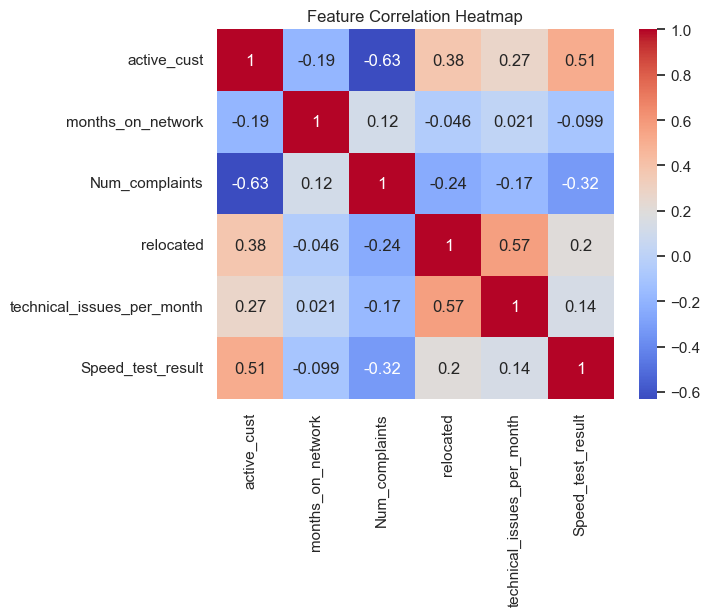

In [15]:
sns.heatmap(data.select_dtypes(include='number').corr(), annot=True, cmap='coolwarm')
plt.title('Feature Correlation Heatmap')
plt.show()

In [16]:
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import (accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay)

In [17]:
# train test split

X = data.drop(columns=['active_cust'])
y = data['active_cust']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

  Logistic Regression
  Test Accuracy:  0.8612
  CV Accuracy:    0.8653 ± 0.0027
              precision    recall  f1-score   support

           0       0.87      0.90      0.88     11570
           1       0.85      0.81      0.83      8427

    accuracy                           0.86     19997
   macro avg       0.86      0.85      0.86     19997
weighted avg       0.86      0.86      0.86     19997



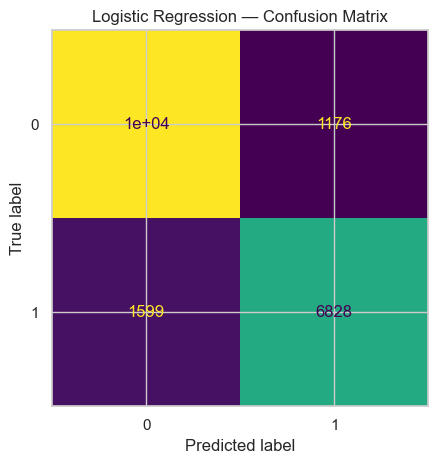

In [18]:
from sklearn.model_selection import cross_val_score

lr = LogisticRegression()
lr.fit(X_train_scaled, y_train)
lr_pred = lr.predict(X_test_scaled)

lr_cv_scores = cross_val_score(lr, X_train_scaled, y_train, cv=5, scoring='accuracy')

print("=" * 45)
print("  Logistic Regression")
print("=" * 45)
print(f"  Test Accuracy:  {accuracy_score(y_test, lr_pred):.4f}")
print(f"  CV Accuracy:    {lr_cv_scores.mean():.4f} ± {lr_cv_scores.std():.4f}")
print(classification_report(y_test, lr_pred))

ConfusionMatrixDisplay(confusion_matrix(y_test, lr_pred)).plot(colorbar=False)
plt.title('Logistic Regression — Confusion Matrix')
plt.tight_layout()
plt.show()

In [19]:
svm = SVC()
svm.fit(X_train_scaled, y_train)
svm_pred = svm.predict(X_test_scaled)

svm_cv_scores = cross_val_score(svm, X_train_scaled, y_train, cv=5, scoring='accuracy')

print("=" * 45)
print("  SVM")
print("=" * 45)
print(f"  Test Accuracy:  {accuracy_score(y_test, svm_pred):.4f}")
print(f"  CV Accuracy:    {svm_cv_scores.mean():.4f} ± {svm_cv_scores.std():.4f}")
print(classification_report(y_test, svm_pred))

ConfusionMatrixDisplay(confusion_matrix(y_test, svm_pred)).plot(colorbar=False)
plt.title('SVM — Confusion Matrix')
plt.tight_layout()
plt.show()

KeyboardInterrupt: 